# Predicting Heart Disease using Machine Learning
This note book loooks into using varies python based ML & DS libraries in an attempt to build 
Ml-model capable of predicting whether or not Somebody  has based on their medical attribute.
## 1, Problem Definition
In Statement:
Given Clinical parameters about patient can we predict whether or not they have heart disease
## 2, Data 
The original data came from the cleavland data fromthe UCI Machine Learning Repository.
There is also  aversion of it available on Kaggle.
## 3, Evaluation 
If we can reach 95% of accuracy at predicting whether or not a patient has heart disease during the proof of the concept 
We will persue the project
## 4, Feature
#### This section is where you get the information about each feature of the data.
** create  a dictionary **
* Age: Patients Age in years (Numeric)
* Sex: Gender (Male : 1; Female : 0) (Nominal)
* cp: Type of chest pain experienced by patient. This term categorized into 4 category.
0 typical angina, 1 atypical angina, 2 non- anginal pain, 3 asymptomatic (Nominal)
trestbps: patient's level of blood pressure at resting mode in mm/HG (Numerical)
chol: Serum cholesterol in mg/dl (Numeric)
* fbs: Blood sugar levels on fasting > 120 mg/dl represents as 1 in case of true and 0 as false (Nominal)
restecg: Result of electrocardiogram while at rest are represented in 3 distinct values
0 : Normal 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of >
0.05 mV) 2: showing probable or definite left ventricular hypertrophyby Estes' criteria (Nominal)
thalach: Maximum heart rate achieved (Numeric)
* exang: Angina induced by exercise 0 depicting NO 1 depicting Yes (Nominal)
oldpeak: Exercise induced ST-depression in relative with the state of rest (Numeric)
* slope: ST segment measured in terms of slope during peak exercise
0: up sloping; 1: flat; 2: down sloping(Nominal)
ca: The number of major vessels (0–3)(nominal)
* thal: A blood disorder called thalassemia
0: NULL 1: normal blood flow 2: fixed defect (no blood flow in some part of the heart) 3: reversible defect (a blood flow is observed but it is not normal(nominal)
* target: It is the target variable which we have to predict 1 means patient is suffering from heart disease and 0 means patient is normal.


In [1]:
# preparing our tools
# we are going to use numpy, matplotliband pandas for data analysis and manipulation
# Regular EDA(exploratory Data Analysis) and Plotting Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
 # we want our lots to appear in the notebook
%matplotlib inline 
# Models from sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
# model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.metrics import RocCurveDisplay




## 1, Data Exploration(exploratory data analysis(EDA))
* The goal is  to find more about the data and become a subject mattet expert on the data 
* 1, What quetions are we trying to solve?
* 2,What kind of data do we have and how do we treat diffrent types?
* 3,what is missing from the data & how do you deal with that?
* 4, Where are the outliers and why should you care abt that?
* 5, How can you add, change or remove features to get more out of data?


In [2]:
import os
print("cwd:", os.getcwd())
print("data files:", os.listdir("../data"))



cwd: c:\Users\UserK\Desktop\MIlestone_project1\Heart-Disease-ml-project\Notebooks
data files: ['6.1 heart-disease.csv']


In [3]:
df = pd.read_csv("../data/6.1 heart-disease.csv")

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [6]:
# let's find how many of of each class there
df.target.value_counts()

target
1    165
0    138
Name: count, dtype: int64

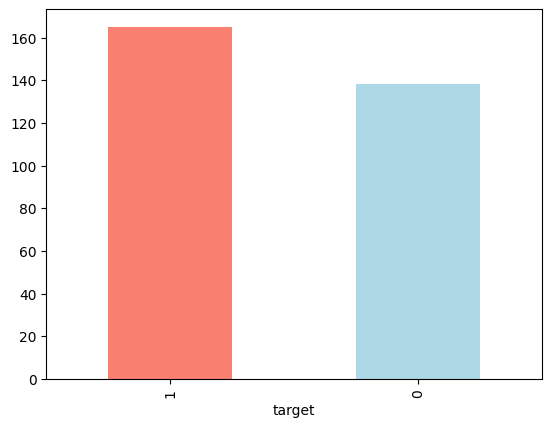

In [7]:
# visualizing the clases
df.target.value_counts().plot(kind="bar", color=["salmon","lightblue"]);

In [8]:
# let us have more information about our data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [9]:
# do we have not numeric columns 
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [10]:
# describe our data numerically
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Heart Disease Frequency according to sex 

In [11]:
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [12]:
# compare sex with target
pd.crosstab(df.target,df.sex)

sex,0,1
target,,
0,24,114
1,72,93


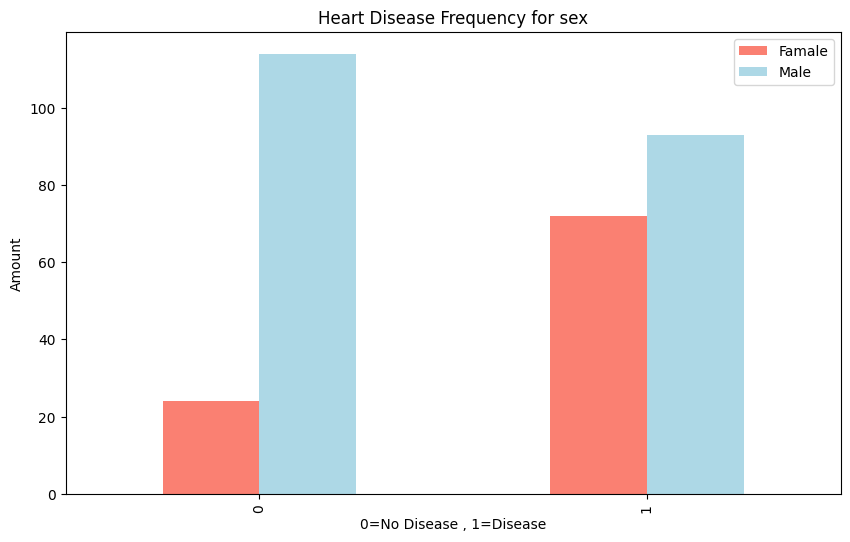

In [13]:
# create plot of  acrosstab
pd.crosstab(df.target,df.sex).plot(kind="bar",
                                   color=["salmon","lightblue"],
                                   figsize=(10,6))
plt.title("Heart Disease Frequency for sex")
plt.xlabel("0=No Disease , 1=Disease")
plt.ylabel("Amount")
plt.legend(["Famale","Male"]);

#### Age Vs. Max Heart Rate for Heart Disease

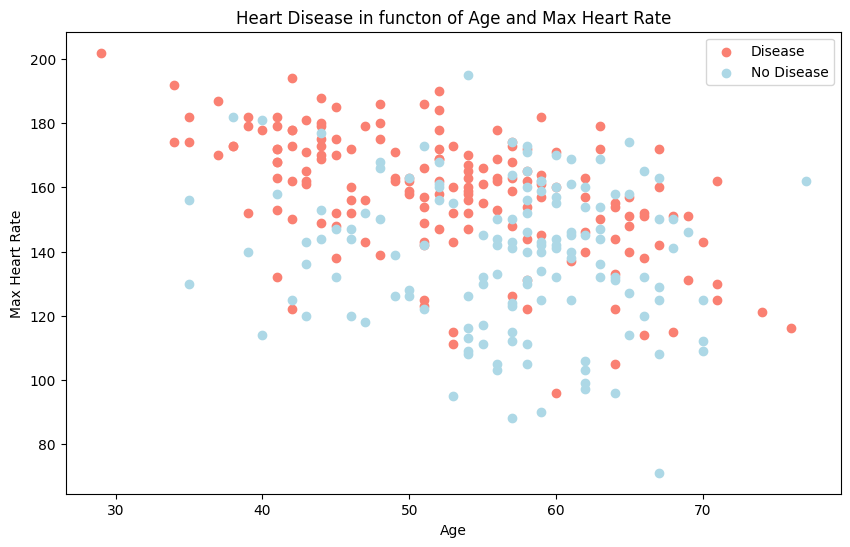

In [14]:
# create another figure 
plt.figure(figsize=(10,6))
# scatter with +ve examples
plt.scatter(df.age[df.target==1],
            df.thalach[df.target==1],
            color="salmon")
plt.scatter(df.age[df.target==0],
            df.thalach[df.target==0],
            color="lightblue")
plt.title("Heart Disease in functon of Age and Max Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.legend(["Disease","No Disease"]);


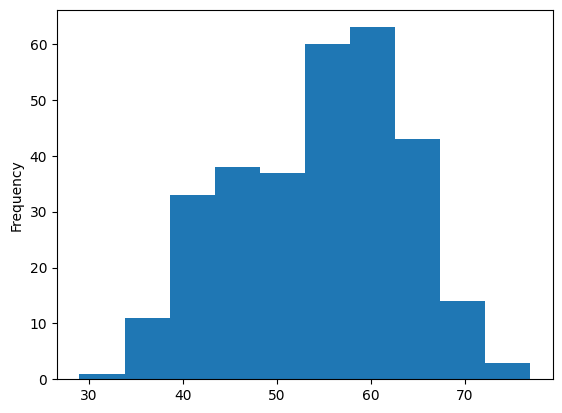

In [15]:
# check the distribution of the age column with a histogram
df.age.plot.hist();

### Heart Disease Frequency Per Chest Pain Type
cp: Type of chest pain experienced by patient. This term categorized into 4 category.
0 typical angina, 1 atypical angina, 2 non- anginal pain, 3 asymptomatic (Nominal)
trestbps: patient's level of blood pressure at resting mode in mm/HG (Numerical)

In [16]:
pd.crosstab(df.cp,df.target)


target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


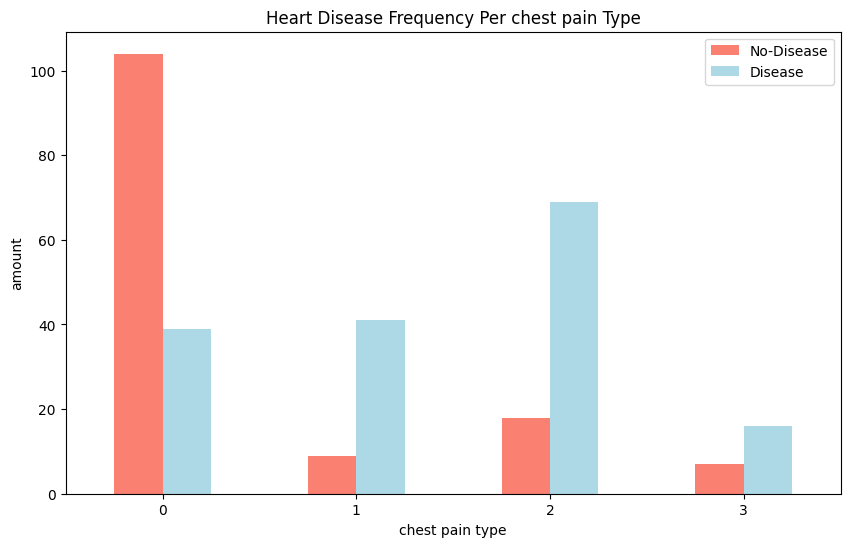

In [17]:
pd.crosstab(df.cp,df.target).plot(kind="bar",
                                  figsize=(10,6),
                                  color=["salmon","lightblue"])
plt.title("Heart Disease Frequency Per chest pain Type")
plt.xlabel("chest pain type")
plt.ylabel("amount")
plt.legend(["No-Disease","Disease"])
plt.xticks(rotation=0);


In [18]:
# make a correlation matrix
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


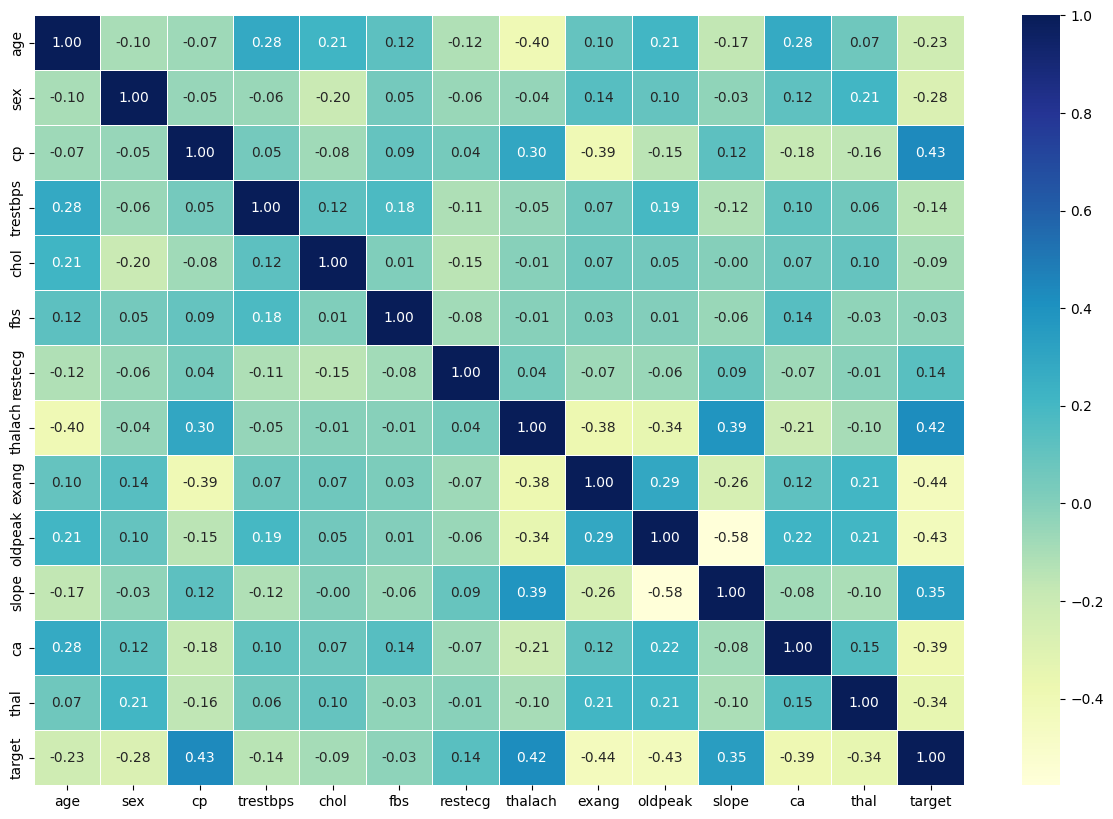

In [19]:
# let us make our correlation matrix more prettier
corr_matrix=df.corr()
fig,ax=plt.subplots(figsize=(15,10))
ax=sns.heatmap(corr_matrix,
               annot=True,
               linewidth=0.5,
               fmt=".2f",
               cmap="YlGnBu")


### 5.Modelling 
we're going to use 3 different Machine Learning Classification model
1. Logistic Regression
2. K-Nearest Neighbours Classifier
3. Random Forest Classifier

In [20]:
# split data in to X and Y
X=df.drop("target",axis=1)
Y=df["target"]
# split data in to train and test set
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2)

In [21]:
# put all our 3 models in dictionary
models={
    "Logistic Regression":LogisticRegression(),
    "KNN":KNeighborsClassifier(),
    "RandomForest":RandomForestClassifier()
}
def fit_and_score(models,x_train,x_test,y_train,y_test):
    """
    fits and evaluates diffrent models
    """
    # set random seed
    np.random.seed(42)
    # make dictionary to keep model scores
    model_scores={}

    for name, model in models.items():
        model.fit(x_train,y_train)
        model_scores[name]=model.score(x_test,y_test)
    return model_scores

In [22]:
models_score=fit_and_score(models=models,
                           x_train=x_train,
                           x_test=x_test,
                           y_train=y_train,
                           y_test=y_test)
models_score

c:\Users\UserK\Desktop\MIlestone_project1\Heart-Disease-ml-project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.8360655737704918,
 'KNN': 0.5737704918032787,
 'RandomForest': 0.8360655737704918}

<Axes: >

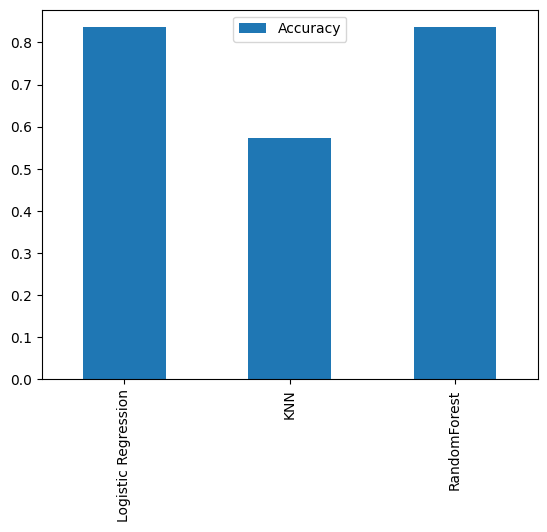

In [23]:
# compare models
model_compare=pd.DataFrame(models_score,index=['Accuracy'])
model_compare.T.plot.bar()

### Hyperparameter Tunning
now we have got the baseline ...and we know a model's first prediction are not always the best

* let us look at the following:
1. Hyperparameter Tunning
2. Feature Importance 
3. Confusion matrix
4. cross validation
5. precision 
6. recall
7. F1 score
8. Classification Report
9. Roc curve
10. Area under curve




### HyperParameter Tunning

In [24]:
# let's tune KNN
np.random.seed(42)
train_scores=[]
test_scores=[]
# create alist of values for n-neighbors
neighbor=range(1,21)
# set up KNN instance
knn=KNeighborsClassifier()
# loop through diffrent neighbors
for i in neighbor:
    knn.set_params(n_neighbors=i)
# fit the algorthim
    knn.fit(x_train,y_train)
    train_scores.append(knn.score(x_train,y_train))
# update the score 
    test_scores.append(knn.score(x_test,y_test))

In [25]:
train_scores

[1.0,
 0.78099173553719,
 0.7727272727272727,
 0.7727272727272727,
 0.756198347107438,
 0.7520661157024794,
 0.7479338842975206,
 0.7355371900826446,
 0.7231404958677686,
 0.7148760330578512,
 0.71900826446281,
 0.71900826446281,
 0.7066115702479339,
 0.7107438016528925,
 0.7231404958677686,
 0.7066115702479339,
 0.7024793388429752,
 0.6983471074380165,
 0.7107438016528925,
 0.7024793388429752]

In [26]:
test_scores

[0.5573770491803278,
 0.5573770491803278,
 0.5245901639344263,
 0.6229508196721312,
 0.5737704918032787,
 0.6229508196721312,
 0.5901639344262295,
 0.5901639344262295,
 0.5901639344262295,
 0.6065573770491803,
 0.639344262295082,
 0.6229508196721312,
 0.5901639344262295,
 0.6065573770491803,
 0.5901639344262295,
 0.6065573770491803,
 0.5901639344262295,
 0.5901639344262295,
 0.6065573770491803,
 0.6065573770491803]

Maximum KNN score on the test data:63.93


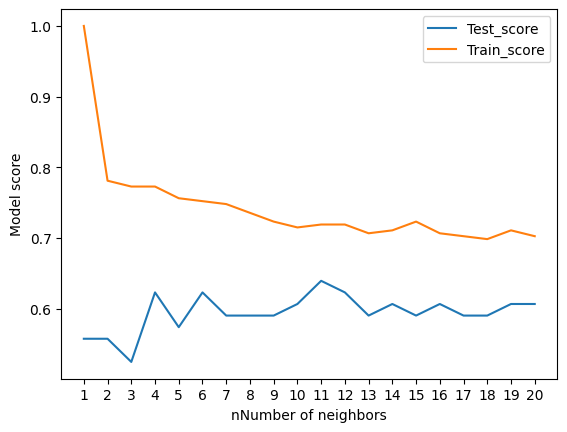

In [27]:
# visualize it
plt.plot(neighbor,test_scores,label="Test_score")
plt.plot(neighbor,train_scores,label="Train_score")
plt.xticks(range(1,21))
plt.xlabel("nNumber of neighbors")
plt.ylabel("Model score")
plt.legend()
print(f"Maximum KNN score on the test data:{max(test_scores)*100:.2f}")

we are going to tune:
* LogisticRegression
* RandomForestClassifier
...using RandomizedSearchCv

In [28]:
# create hyperparameter grid for logistic regression
log_reg_grid={
    "C":np.logspace(-4,4,20),
    "solver":["liblinear"],
}
# create a hyperparameter grid for RandomForestClassifier
rf_grids={
    "n_estimators":np.arange(10,1000,50),
    "max_depth":np.arange(2,20,2),
    "min_samples_leaf":np.arange(1,20,2)
}
# Tune LogisticRegression
np.random.seed(42)
rs_log_reg=RandomizedSearchCV(LogisticRegression(),
                              param_distributions=log_reg_grid,
                              cv=5,
                              n_iter=20,
                              verbose=True)
# fit randomized HyperParameters search model for LogisticRegression
rs_log_reg.fit(x_train,y_train)
# best params
rs_log_reg.best_params_
# evaluate RandomizedSearchCv for Logistic Rgression
rs_log_reg.score(x_test,y_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


0.8524590163934426

In [29]:
models_score

{'Logistic Regression': 0.8360655737704918,
 'KNN': 0.5737704918032787,
 'RandomForest': 0.8360655737704918}

In [30]:
# tune random forest classifier
np.random.seed(42)
rs_rf=RandomizedSearchCV(RandomForestClassifier(),
                         param_distributions=rf_grids,
                         cv=5,
                         n_iter=20,
                         verbose=True)
# fit RandomSearchCv for RandomForestClassifier
rs_rf.fit(x_train,y_train)
# evaluate RandomizedSearchClassifier
rs_rf.score(x_test,y_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


0.8524590163934426

In [31]:
# diffrent hyperparametres for RandomForestClassifier model
rf_grids={
    "n_estimators":[100,200,300],
    "max_depth":[5,10,15],
    "min_samples_leaf":[1,2,4]
}
gs_rf=GridSearchCV(RandomForestClassifier(),
                   param_grid=rf_grids,
                   cv=5,
                   verbose=True)
# fit hyperparameter search model
gs_rf.fit(x_train,y_train)
# evaluate the model
gs_rf.score(x_test,y_test)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


0.8524590163934426

## Evaluating our tunned Machine Learning Classifier
beyond accuracy
* Roc curve and AUc score
* confusion matrix 
* classification report 
* precision 
* Recall
* F1-score
...it would be great if cross-validation was used where  possible
when we evaluate a model, it's always comparing how our trained model predicitions compared to truth label
* To make comparisons & evaluate our trained model , first we need to make predictions


In [32]:
# make predictions with tunned model
y_preds=gs_rf.predict(x_test)
y_preds

array([1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1])

In [33]:
y_test

157    1
97     1
243    0
14     1
240    0
      ..
83     1
269    0
34     1
233    0
33     1
Name: target, Length: 61, dtype: int64

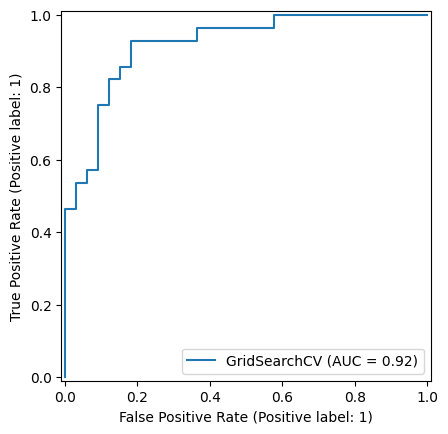

In [34]:
# plot roc curve and calculate auc metric 
RocCurveDisplay.from_estimator(gs_rf, x_test, y_test)
plt.show()

[[27  6]
 [ 3 25]]


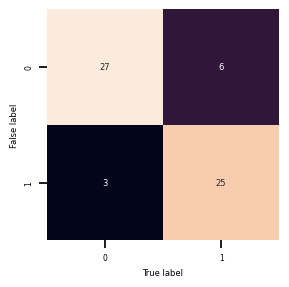

In [35]:
# confusion matrix
print(confusion_matrix(y_test,y_preds))
sns.set_context("notebook",font_scale=0.5)
def plot_conf(y_test,y_preds):
    fig,ax=plt.subplots(figsize=(3,3))
    ax=sns.heatmap(confusion_matrix(y_test,y_preds),
                   annot=True,
                   cbar=False)
    plt.xlabel("True label")
    plt.ylabel("False label")
plot_conf(y_test,y_preds)

In [36]:
# printing classification report 
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.90      0.82      0.86        33
           1       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



In [37]:
# calculate the evaluation metrics using cross validation 
gs_rf.best_params_


{'max_depth': 15, 'min_samples_leaf': 4, 'n_estimators': 100}

In [38]:
clf=RandomForestClassifier(n_estimators= 200,
                           max_depth= 10,
                           min_samples_leaf= 4)
cross_acc=cross_val_score(clf,X,Y,cv=5, scoring="accuracy")
cross_acc

array([0.78688525, 0.90163934, 0.81967213, 0.86666667, 0.76666667])

In [39]:
# function for all evaluation metrics
def cross_val(model,X,Y,metrics):
    results={}
    for metric in metrics:
        score=cross_val_score(model,X,Y,scoring=metric)
        score= f"{float(np.mean(score)):.2f}"
        results[metric]=score
    return results
metrics = ["accuracy", "precision", "recall", "f1"]
cross_results=cross_val(clf,X,Y,metrics)

    



### Finding the Feature Imporatnce For Our Model
* Feature Importance is another way sa asking "which features contributed most to the outcome of the model?" and 
how did they contributed?

In [41]:
# fit an instacnce of RandomForets
clf.fit(x_train,y_train)
# get importance Value 
importances = clf.feature_importances_
importances

array([0.06576088, 0.02948595, 0.17009743, 0.04247128, 0.05354241,
       0.00328052, 0.01897358, 0.11946504, 0.07978704, 0.14044881,
       0.03334046, 0.1463429 , 0.0970037 ])

In [43]:
# match feature imporatnce with to columns
feature_dict=dict(zip(df.columns,list(clf.feature_importances_)))
feature_dict

{'age': np.float64(0.06576087616732021),
 'sex': np.float64(0.029485951884606957),
 'cp': np.float64(0.17009742856007293),
 'trestbps': np.float64(0.04247127555113787),
 'chol': np.float64(0.05354241389433624),
 'fbs': np.float64(0.003280524221723034),
 'restecg': np.float64(0.018973580120715847),
 'thalach': np.float64(0.11946504069561259),
 'exang': np.float64(0.07978703820992253),
 'oldpeak': np.float64(0.14044881477456372),
 'slope': np.float64(0.033340457438712945),
 'ca': np.float64(0.14634290167961253),
 'thal': np.float64(0.09700369680166271)}

<Axes: title={'center': 'Feature Importance'}>

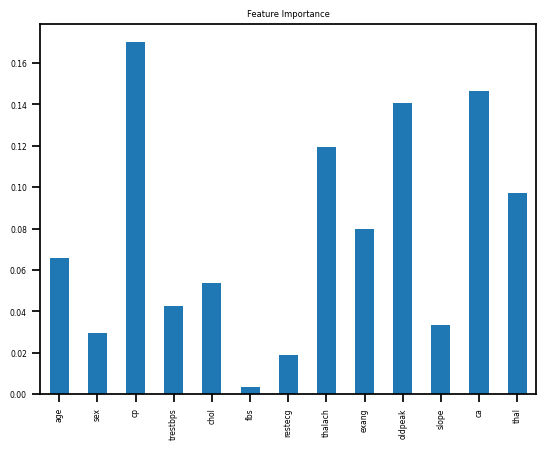

In [45]:
feature_df=pd.DataFrame(feature_dict,index=[0])
feature_df.T.plot.bar(title='Feature Importance',legend=False)

## 6. Expermentation
* If yo have not hit your evaluation metric yet..ask your self:
   * could you collect more data?
   * could you try a better model,  like CAtBoost or XBoost 
   * could you improve the current models
   * if your model is good enough (you have hit your evaluation metric , how would you export it and share it with others)

In [47]:
# Export and Save amodel
import joblib
joblib.dump(clf,'best_model.joblib')

['best_model.joblib']